In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable

In [3]:
# interaction and lattice definition

BASE_A = np.zeros(3)
BASE_B = np.array([1/np.sqrt(3),0,0])
LATTICE_VECTOR_2 = np.array([0,1,0])
LATTICE_VECTOR_1 = 1/2*np.array([np.sqrt(3),1,0])
LATTICE_VECTOR_1_ALTERNATIVE = np.sqrt(3)*np.array([1,0,0])

REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
REZI_1 = 4*np.pi/np.sqrt(3)*np.array([1,0,0])
# alternative can't be used, gives wrong results
REZI_1_ALTERNATIVE = 2*np.pi/np.sqrt(3)*np.array([1,0,0])
REZI_2_ALTERNATIVE = 2*np.pi*np.array([0,1,0])


def bare_interaction(Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5
        if i == 2:
            potential += 6/ Del_R**5
    potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return potential

def bare_interaction_coulomb(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    beta = 0.04
    potential = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R >interaction_radius+0.01:
        return 0
    if i==j:
        # return 0
        potential += 1
    potential -= 3*Delta_R_vec[i]*Delta_R_vec[j]/Del_R**2
    potential *= beta/2/Del_R**3
    return potential
        

def bare_interaction_coulomb_onsite(i: int, j:int) -> float:
    Vb = -0.1
    if i ==2 or j==2:
        return 0
    elif i == j:
        return 1
    elif i ==0:
        return -1j*Vb
    else:
        return 1j*Vb
    
def no_onsite_interaction(i: int, j:int) -> float:
    return 0

b = 4*np.pi/3/np.sqrt(3)
k3 = b*np.array([np.sqrt(3)/4,3/4,0])
k1 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k2 = 4*np.pi/3*np.array([1,0,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2
    
def V_1(i, vec, modulus):
    return 3*vec[i]/modulus**5
 


def interaction_VdW(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    """Calculate the Van der Waals interaction between two dipoles."""
    # Delta_R_vec /= 5
    V2 = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    
    if Del_R >interaction_radius+0.01:
        return 0
    V0 = 1/Del_R**3#(1-3*Delta_R_vec[2]**2/Del_R**2)/Del_R**3
    V1 = V_1(i, Delta_R_vec, Del_R)*V_1(j, Delta_R_vec, Del_R)

    if i == j:
        V2 += 3/ Del_R**5
        
        if i == 2:
            V2 += 6/ Del_R**5
    V2 -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return 2*(V0*V2+V1)

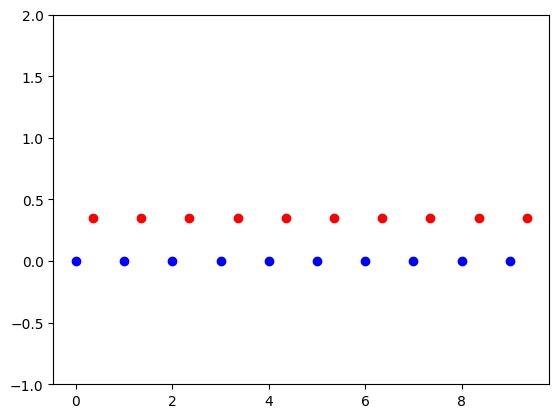

In [ ]:
# create chain
chain_length = 20
latticeA = np.zeros((2,latticeA.shape[1]))
latticeB = np.zeros((2,latticeB.shape[1]))
a = 1
frac = 0.5
alpha = np.pi/4
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])+ np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
fig, ax = plt.subplots(1,1)
ax.scatter(latticeA[0,:],latticeA[1,:], color='blue')
ax.scatter(latticeB[0,:],latticeB[1,:], color='red')
ax.set_ylim(-1,2)

plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


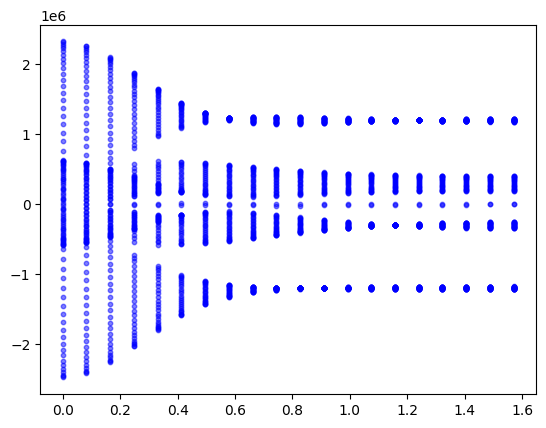

In [53]:
# open lattice consideration


def open_D_mat(alpha,frac,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    a = 1
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])+ np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    dmat = np.zeros((2*chain_length,2*chain_length),dtype=complex)
    if not cut:
        cut = [chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        # print(i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m)
                        if n==m:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] = onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i,j,*cut)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
                        if n==m:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i-2,j-2,*cut)
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i,j-2,*cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i-2,j,*cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB, chain_length

fig, ax = plt.subplots(1,1)
alphas = np.linspace(0, np.pi/2, 20)
chain_length = 51
eigenvals = np.zeros((len(alphas),2*chain_length,2*chain_length+1),dtype=complex)
# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
for i in range(len(alphas)):
  
    dmat, latticeA, latticeB, chain_length = open_D_mat(alphas[i],0.5,chain_length,bare_interaction,no_onsite_interaction,100)
    eig, vecs = np.linalg.eig(dmat)
    eigenvals[i,:,0] = eig
    eigenvals[i,:,1:] = vecs.T
    
    ax.scatter(alphas[i]*np.ones(eig.shape[0]), eig, color='blue', s=10, alpha=0.5)
plt.show()


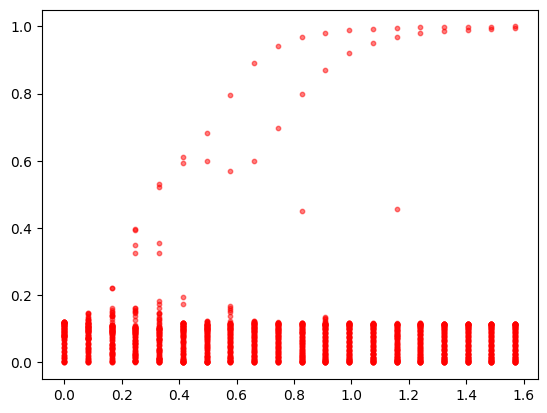

In [54]:
fig, ax = plt.subplots(1,1)
for i in range(len(alphas)):
    edge_indicator = find_edge_states(eigenvals[i,:,:])
    ax.scatter(alphas[i]*np.ones(edge_indicator.shape[0]), edge_indicator, color='red', s=10, alpha=0.5)
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


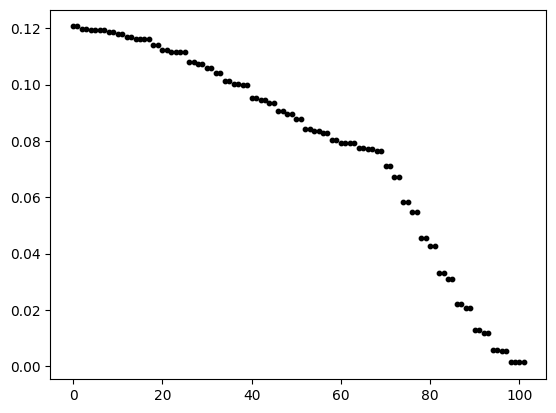

eigenvalue:  [1.20646238e-01+0.j 3.63451543e+05+0.j]


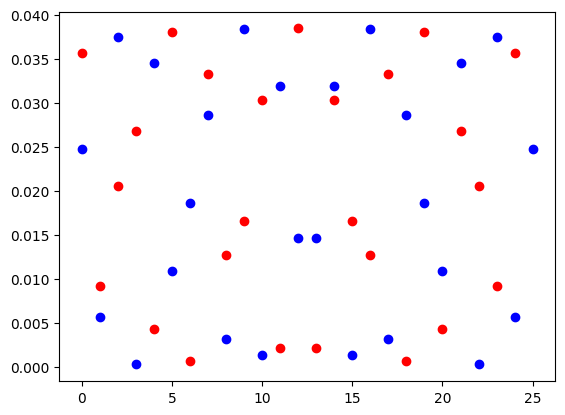

eigenvalue:  [1.20646238e-01+0.j 3.63451543e+05+0.j]


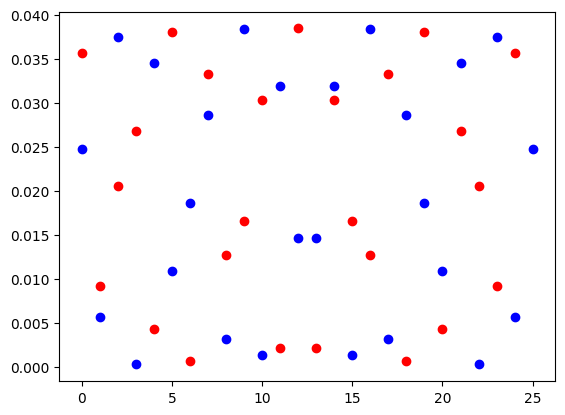

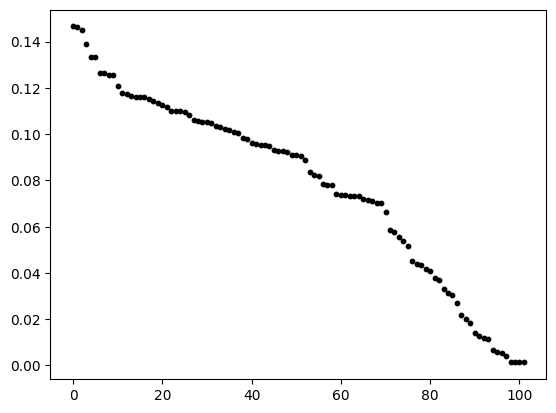

eigenvalue:  [ 1.46535771e-01+0.j -2.59527706e+05+0.j]


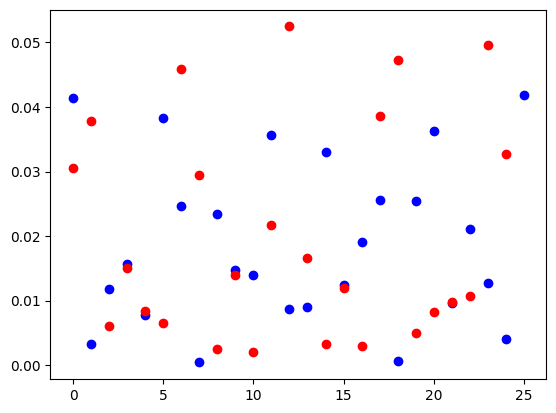

eigenvalue:  [ 1.46535771e-01+0.j -2.59527706e+05+0.j]


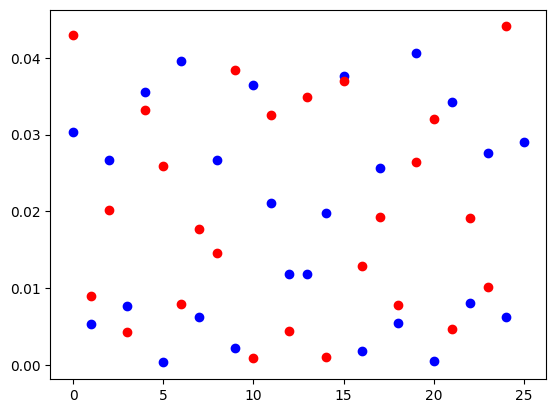

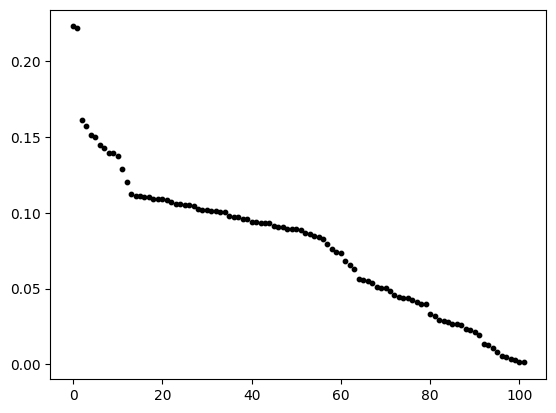

eigenvalue:  [ 2.22792540e-01+0.j -5.01677755e+03+0.j]


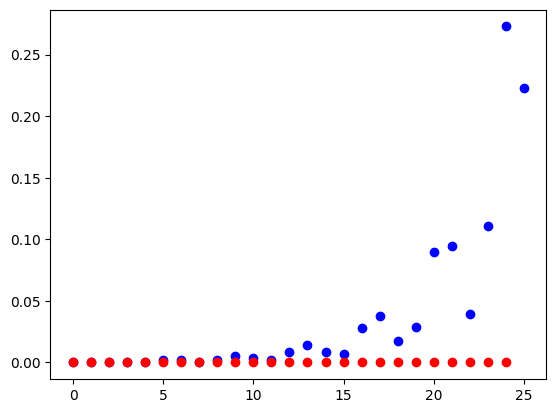

eigenvalue:  [ 2.22792540e-01+0.j -5.01677755e+03+0.j]


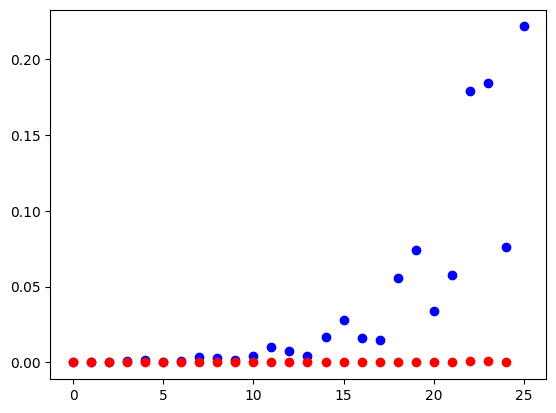

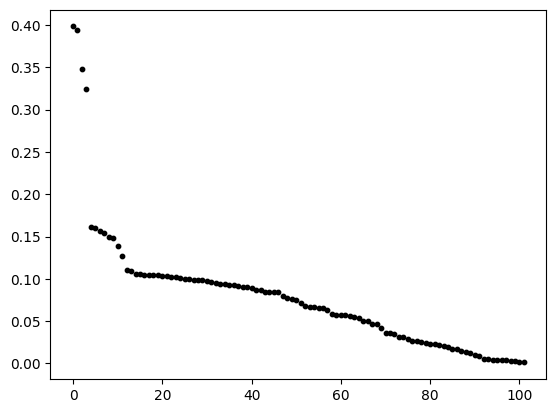

eigenvalue:  [3.98295168e-01+0.j 5.64055533e+03+0.j]


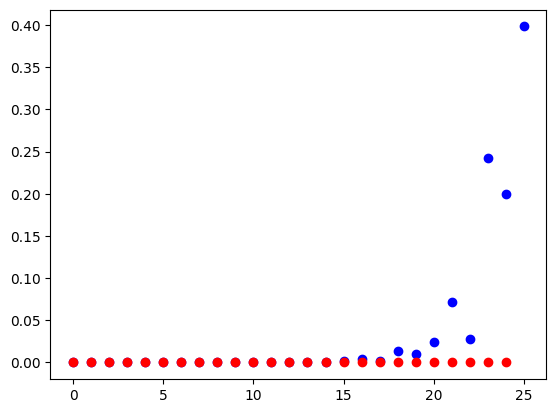

eigenvalue:  [3.98295168e-01+0.j 5.64055533e+03+0.j]


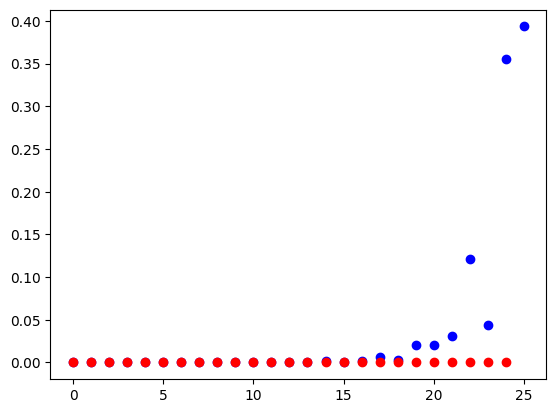

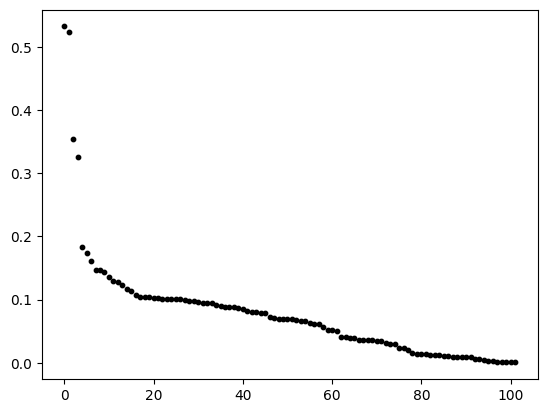

eigenvalue:  [5.32327007e-01+0.j 7.71838313e+03+0.j]


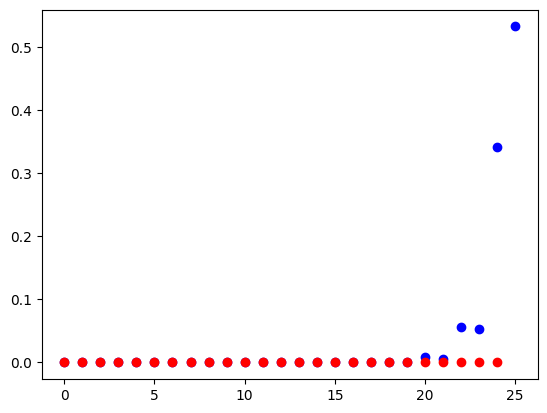

eigenvalue:  [5.32327007e-01+0.j 7.71838313e+03+0.j]


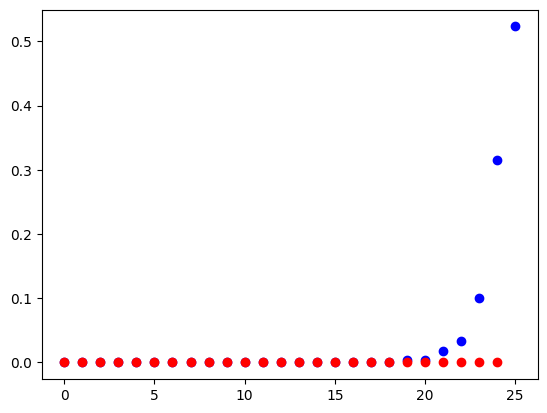

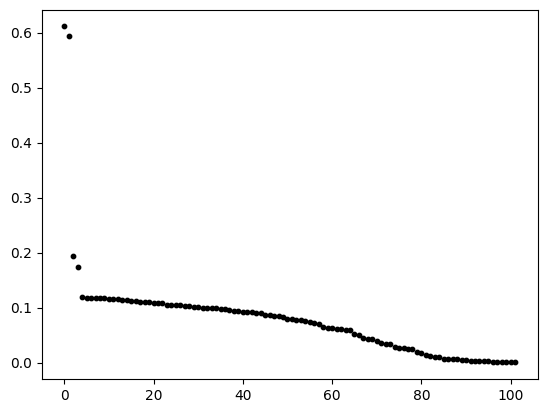

eigenvalue:  [6.11074192e-01+0.j 9.12782667e+03+0.j]


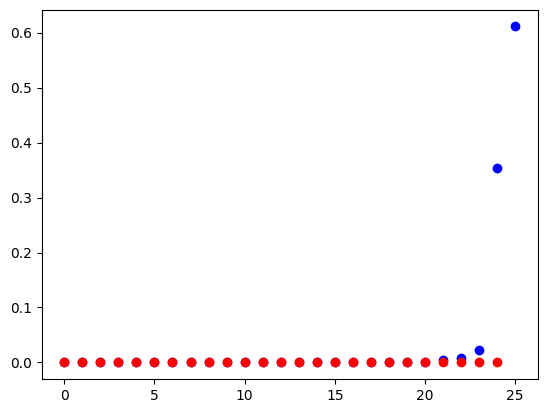

eigenvalue:  [6.11074192e-01+0.j 9.12782667e+03+0.j]


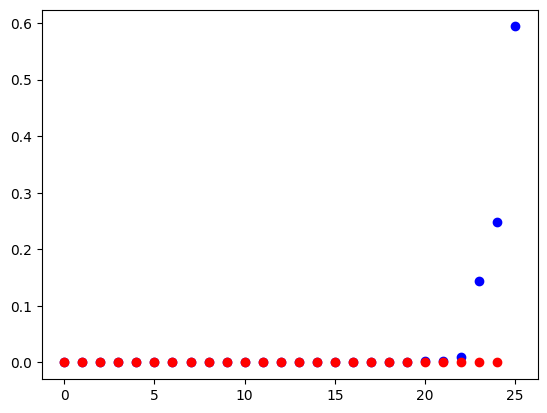

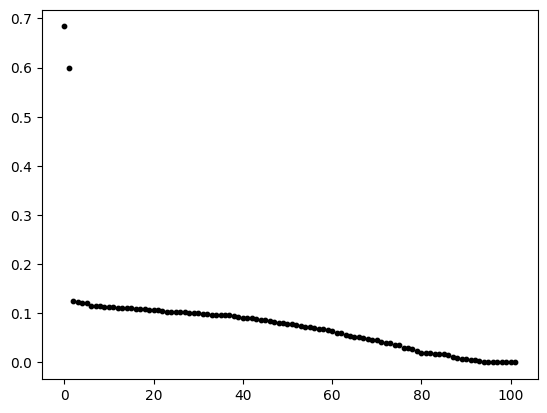

eigenvalue:  [6.83721593e-01+0.j 8.59129815e+03+0.j]


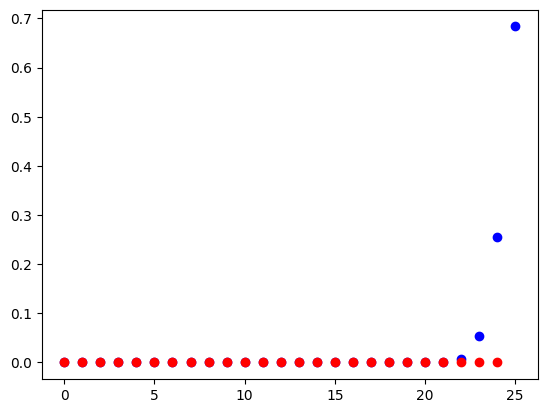

eigenvalue:  [6.83721593e-01+0.j 8.59129815e+03+0.j]


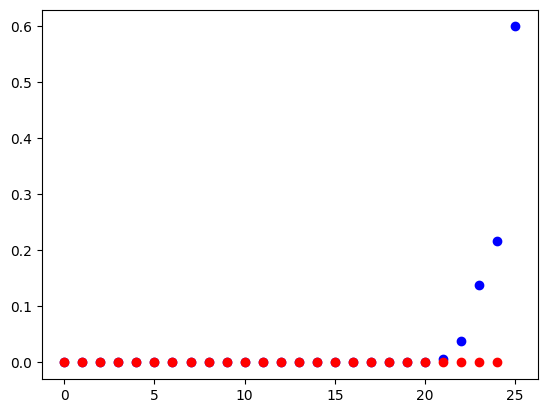

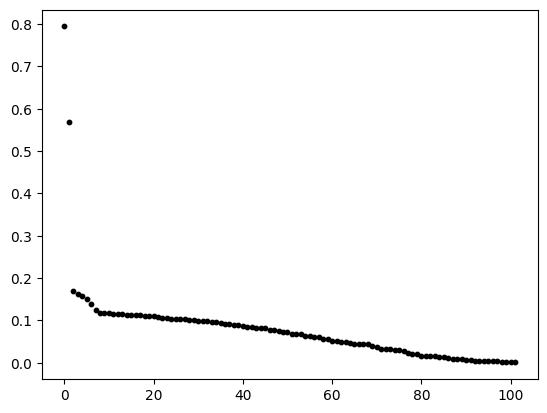

eigenvalue:  [7.94387382e-01+0.j 6.51013010e+03+0.j]


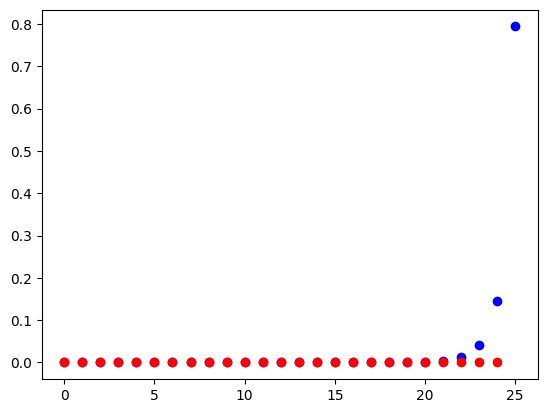

eigenvalue:  [7.94387382e-01+0.j 6.51013010e+03+0.j]


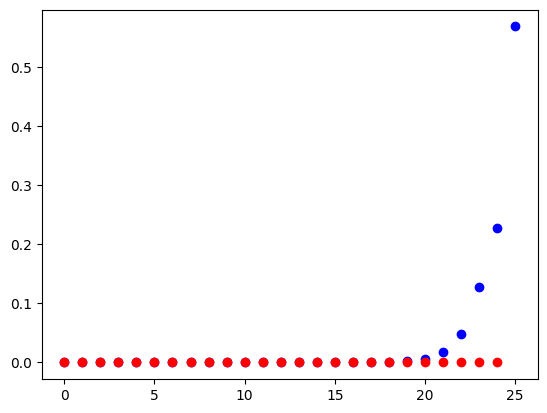

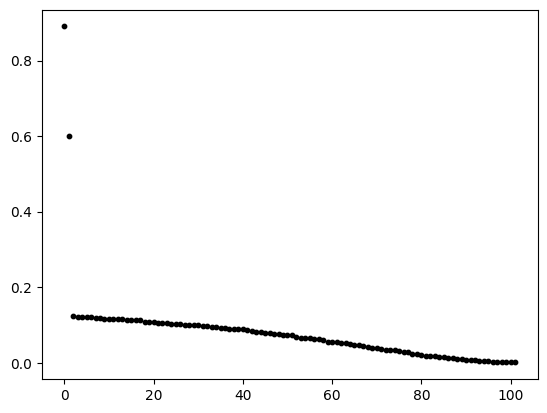

eigenvalue:  [8.90430231e-01+0.j 4.72208168e+03+0.j]


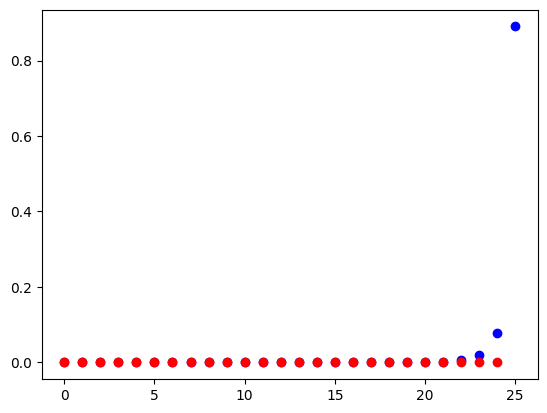

eigenvalue:  [8.90430231e-01+0.j 4.72208168e+03+0.j]


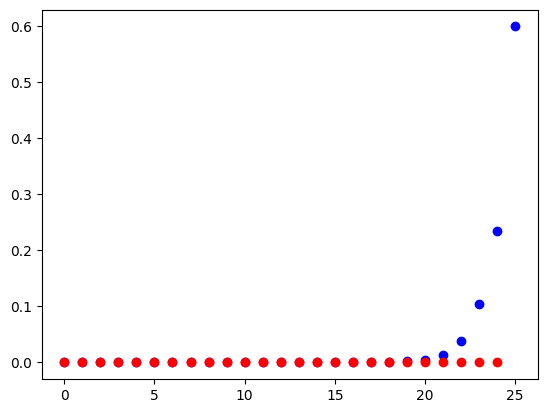

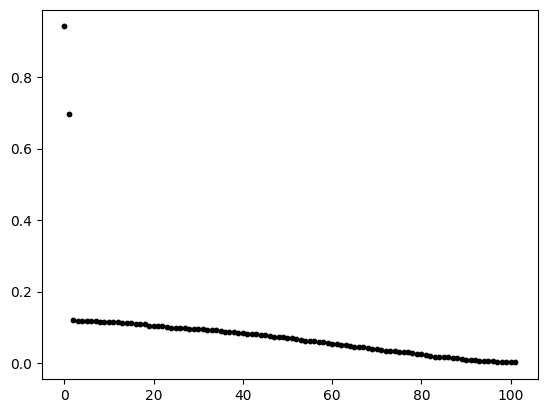

eigenvalue:  [9.41901333e-01+0.j 3.69166541e+03+0.j]


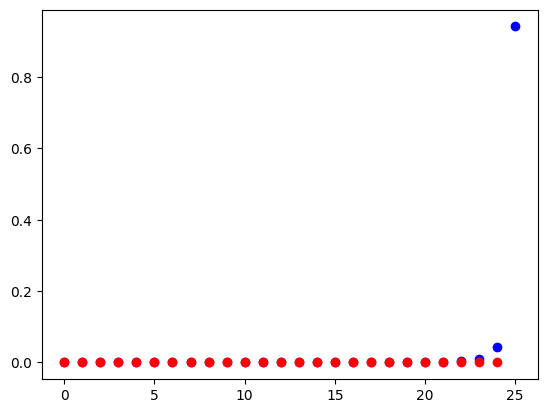

eigenvalue:  [9.41901333e-01+0.j 3.69166541e+03+0.j]


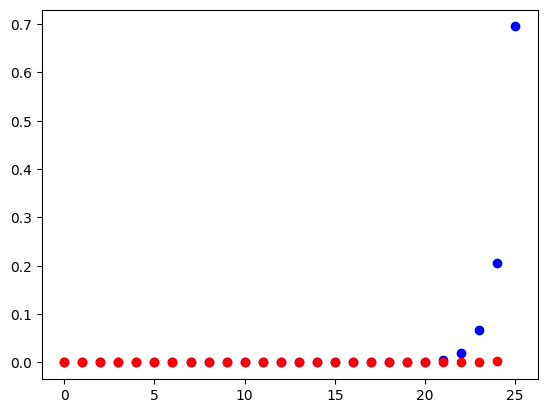

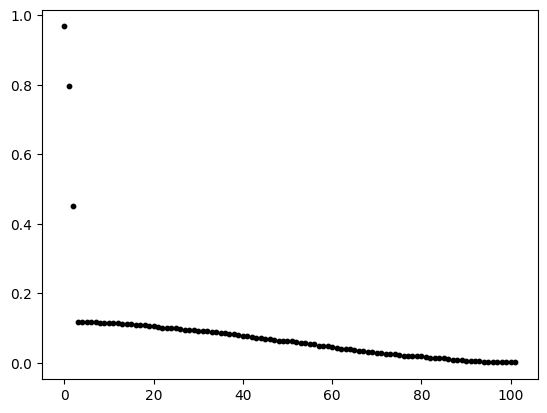

eigenvalue:  [9.67691983e-01+0.j 3.04572523e+03+0.j]


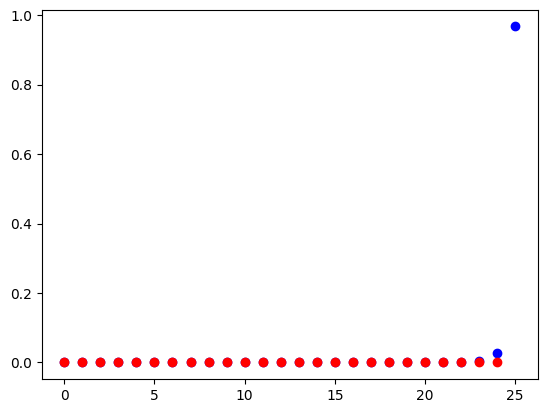

eigenvalue:  [9.67691983e-01+0.j 3.04572523e+03+0.j]


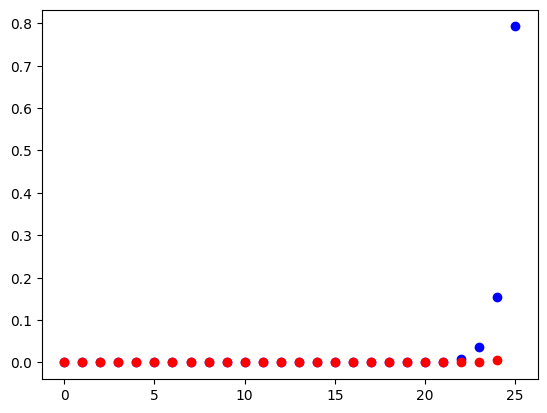

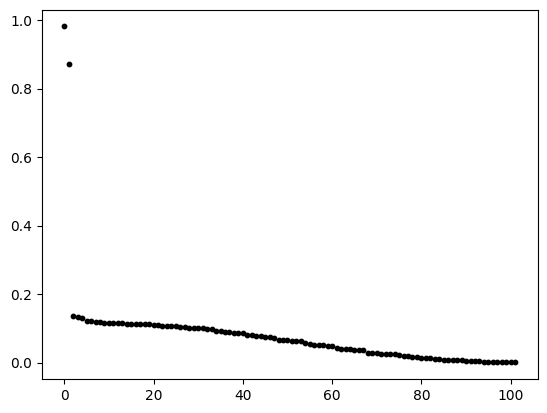

eigenvalue:  [9.81440384e-01+0.j 2.54850040e+03+0.j]


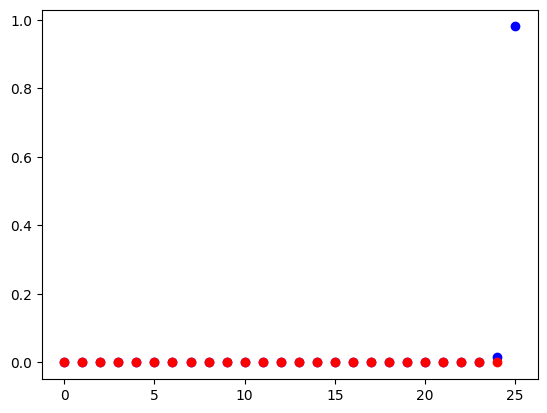

eigenvalue:  [9.81440384e-01+0.j 2.54850040e+03+0.j]


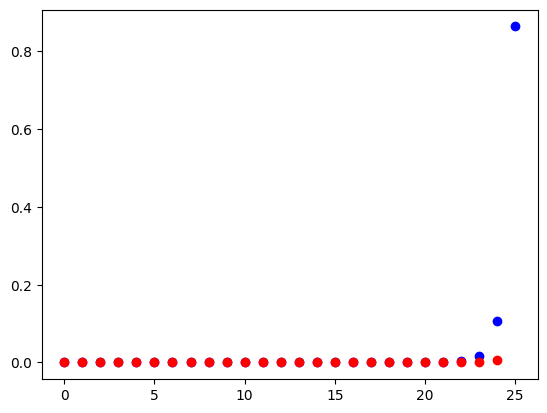

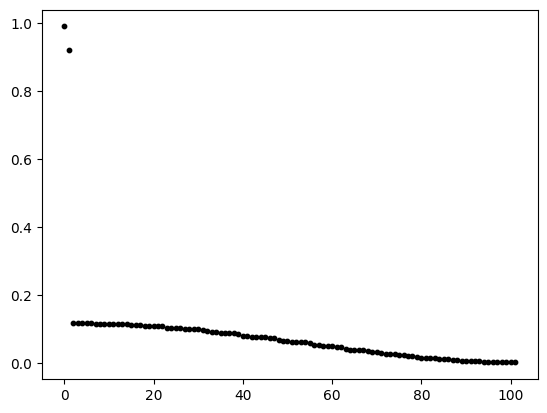

eigenvalue:  [9.89140136e-01+0.j 2.12096782e+03+0.j]


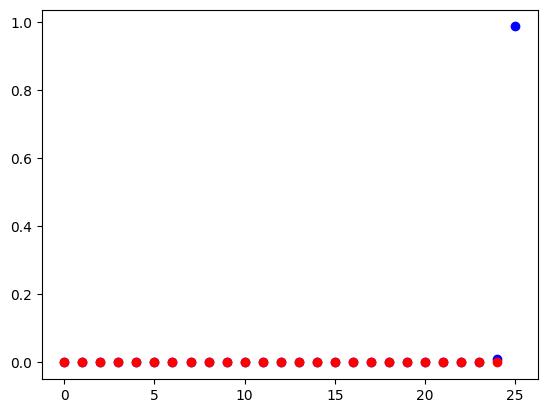

eigenvalue:  [9.89140136e-01+0.j 2.12096782e+03+0.j]


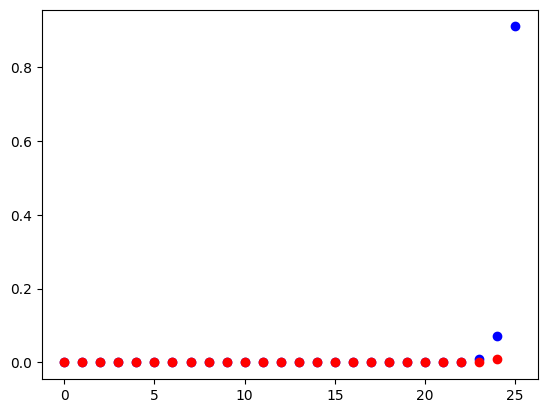

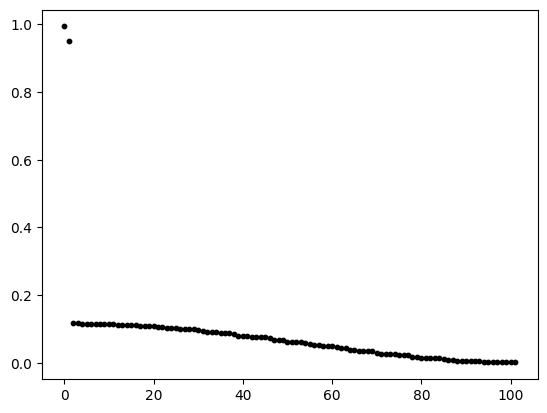

eigenvalue:  [9.93570052e-01+0.j 1.74523990e+03+0.j]


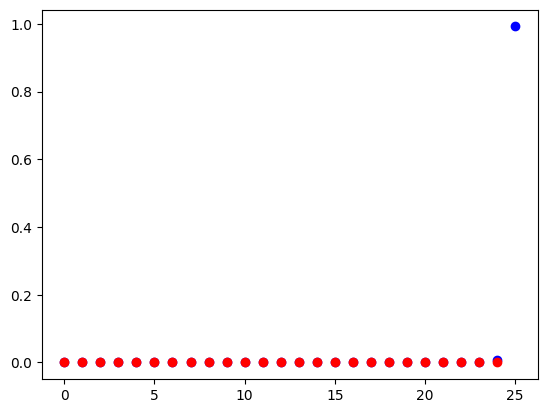

eigenvalue:  [9.93570052e-01+0.j 1.74523990e+03+0.j]


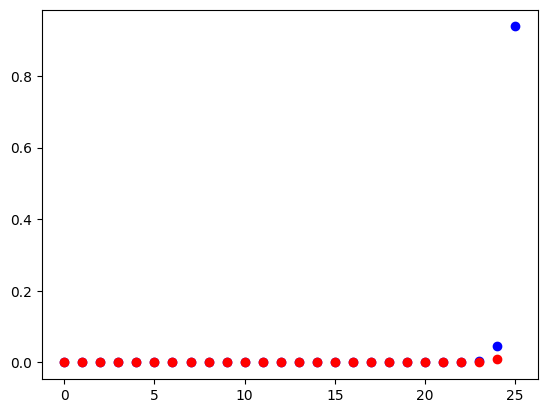

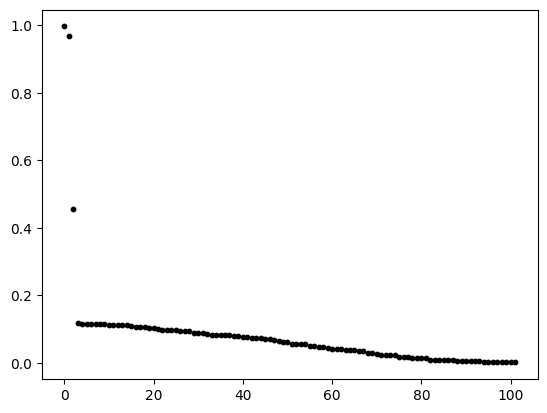

eigenvalue:  [9.96156980e-01+0.j 1.41948623e+03+0.j]


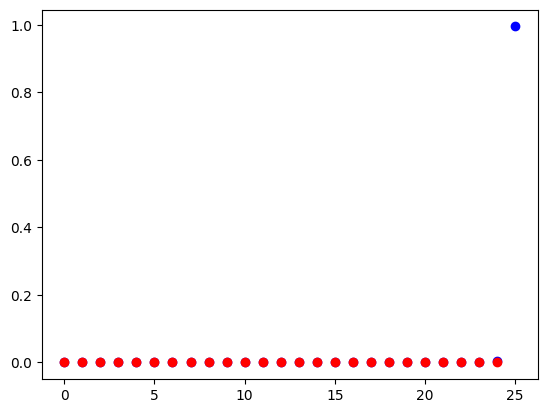

eigenvalue:  [9.96156980e-01+0.j 1.41948623e+03+0.j]


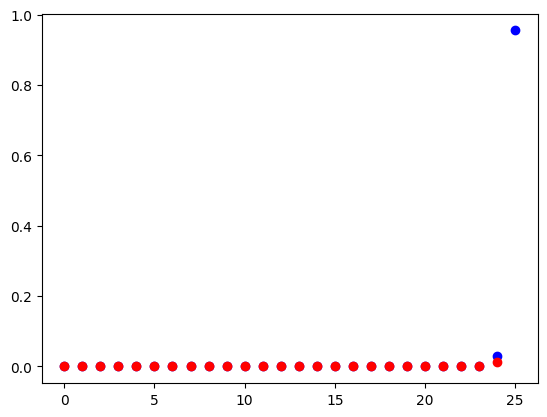

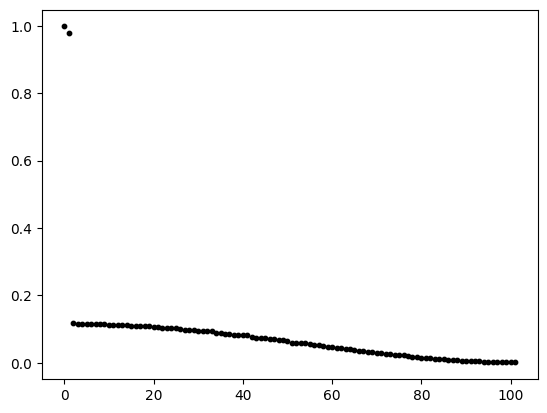

eigenvalue:  [9.97682719e-01+0.j 1.14297222e+03+0.j]


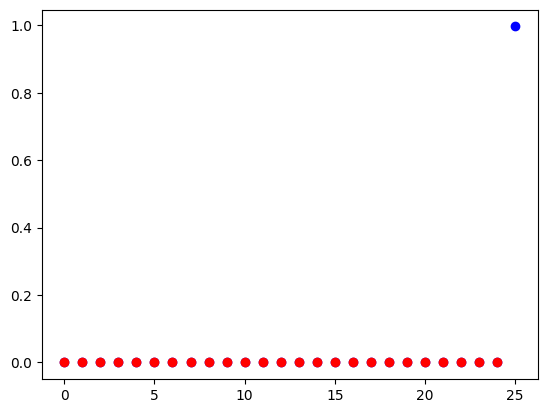

eigenvalue:  [9.97682719e-01+0.j 1.14297222e+03+0.j]


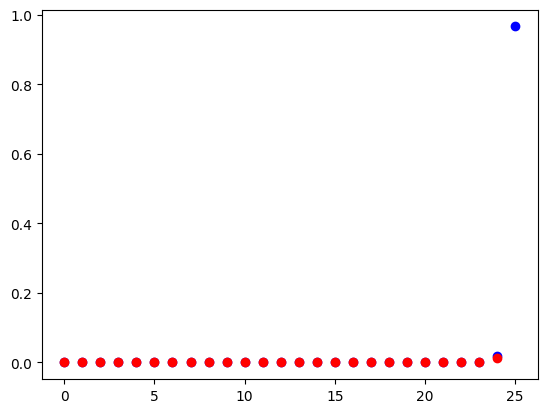

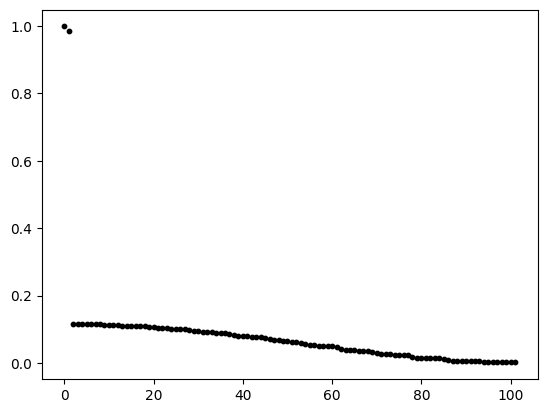

eigenvalue:  [  0.99859001+0.j 912.79630602+0.j]


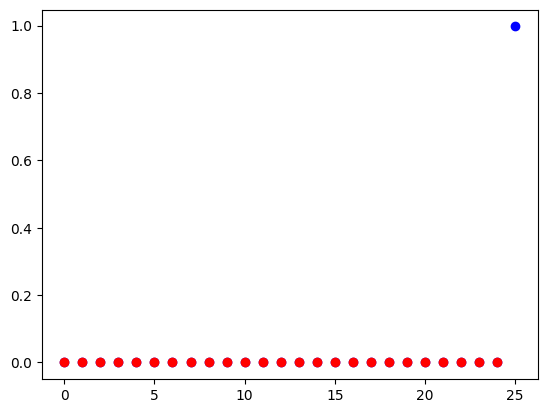

eigenvalue:  [  0.99859001+0.j 912.79630602+0.j]


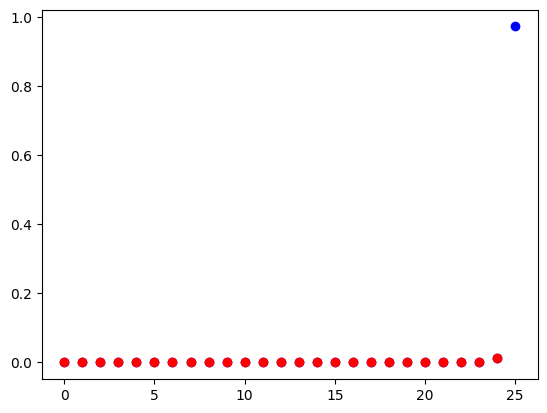

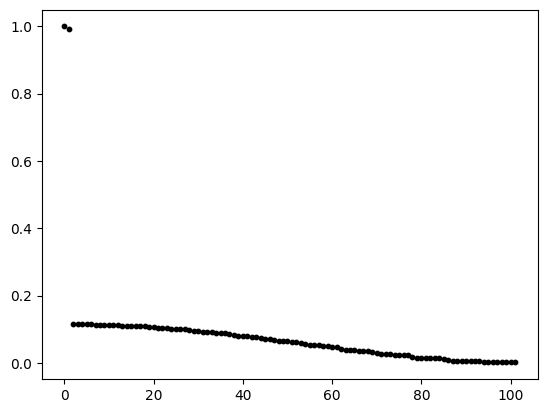

eigenvalue:  [  0.99913372+0.j 724.24181378+0.j]


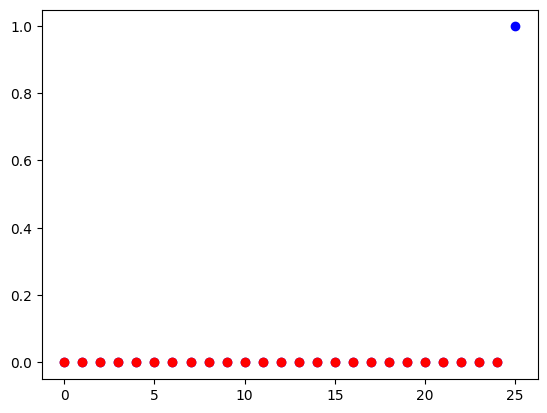

eigenvalue:  [  0.99913372+0.j 724.24181378+0.j]


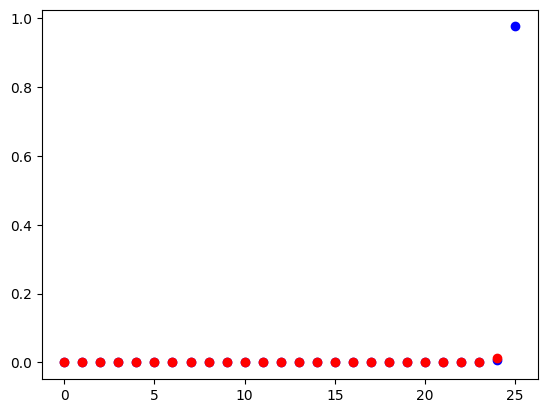

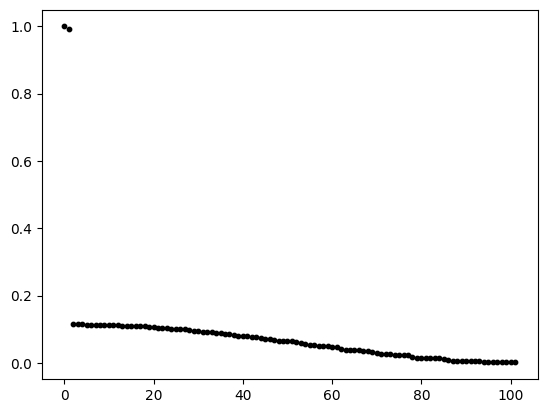

eigenvalue:  [  0.99946188+0.j 571.78570483+0.j]


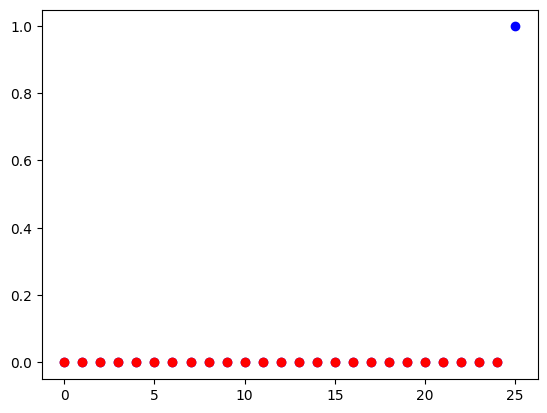

eigenvalue:  [  0.99946188+0.j 571.78570483+0.j]


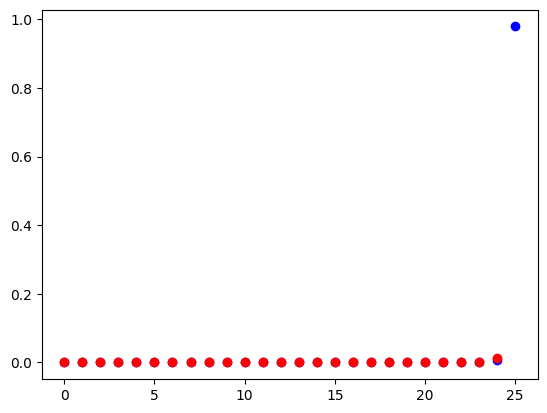

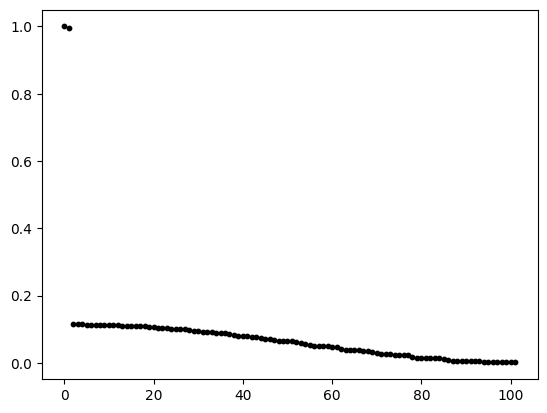

eigenvalue:  [  0.99966098+0.j 449.89632305+0.j]


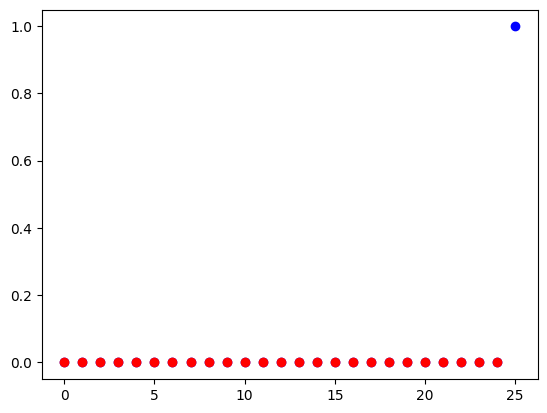

eigenvalue:  [  0.99966098+0.j 449.89632305+0.j]


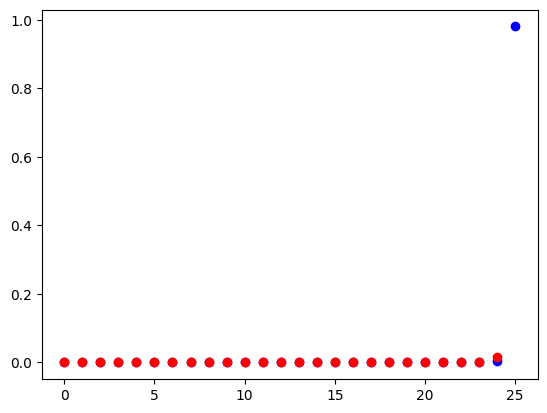

In [56]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)
# eigenvals = sort_eigenvalues(eig, vecs)
def find_edge_states(vec):
    return np.abs(vec[:,1])**2+np.abs(vec[:,latticeA.shape[1]])**2+np.abs(vec[:,latticeA.shape[1]+1])**2+np.abs(vec[:,(latticeA.shape[1])*2])**2\
    + np.abs(vec[:,2*latticeA.shape[1]+1])**2+np.abs(vec[:,latticeB.shape[1]+2*latticeA.shape[1]])**2+np.abs(vec[:,2*latticeA.shape[1]+latticeB.shape[1]+1])**2+np.abs(vec[:,2*latticeA.shape[1]+(latticeB.shape[1])*2])**2

# vecA = np.abs(eigenvals[:,1:latticeA.shape[1]+1])**2 + np.abs(eigenvals[:,chain_length+1:chain_length+latticeA.shape[1]+1])**2
# vecB = np.abs(eigenvals[:,latticeA.shape[1]+1:chain_length+1])**2 + np.abs(eigenvals[:,chain_length+latticeA.shape[1]+1:])**2

for n in range(alphas.shape[0]):
    edge_indicator = find_edge_states(eigenvals[n,:,:])
    edge = sort_eigenvalues(edge_indicator, eigenvals[n,:,:])[::-1]
    fig, ax = plt.subplots(1,1)
    ax.scatter(np.arange(edge.shape[0]), edge[:,0], color='black', s=10)
    plt.show()
    for ind in range(2):
        fig, ax = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax.scatter(latticeA[0,:],vecA, color='blue')
        ax.scatter(latticeB[0,:],vecB, color='red')
        plt.show()